Tutorial 5

1. Use the salary data
2. Handles Incomplete, noise and inconsistent values

# Data Preprocessing-Cleaning
 1. Incomplete (Missing Values)
 2. Noise (Either errors)
 3. Inconsistent

In [ ]:
import numpy as np
import pandas as pd

#pd.read_csv() is a function called from pandas library
#df = pd.read_csv('salary.csv') # this command load salary.csv onto your dataframe named as df.

#You can mount the file on your google drive and load it. To make life easier, just make sure your directory doesn't have spaces
#Example    /Dataset/machine learning <<<This directory has spaces

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Dataset/salary.csv') #load the csv dataset into a 'dataframe' df

#Convert "salary" string to integers
df['Salary'] = df['Salary'].replace(',','',regex=True) #this replace the comma ',' in 55,000 to 55000
df['Salary'] = df['Salary'].astype(int) # this convert the column datatypes from object into numbers , in this case integer

df.head()

Mounted at /content/drive


,Timestamp,Age,Industry,Job title,Context,Salary,Compensation,Currency,Other currency,Salary context,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,55000,0.0,USD,NaN,NaN,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,54600,4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,34000,NaN,USD,NaN,NaN,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,NaN,62000,3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,60000,7000.0,USD,NaN,NaN,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


# Getting the stats for one column/feature

In [ ]:
df['Salary'].mean()

147162.5931258709

In [ ]:
# Getting the stats for all columns

In [ ]:
df.describe()

,Salary,Compensation
count,2.798900e+04,2.071900e+04
mean,1.471626e+05,1.819127e+04
std,5.414698e+06,8.349982e+05
min,0.000000e+00,0.000000e+00
25%,5.400000e+04,0.000000e+00
50%,7.500000e+04,2.000000e+03
75%,1.100000e+05,1.000000e+04
max,8.700000e+08,1.200000e+08


In [ ]:
df['Salary']

,Salary
0,55000
1,54600
2,34000
3,62000
4,60000
...,...
27984,28600
27985,125000
27986,72000
27987,30000


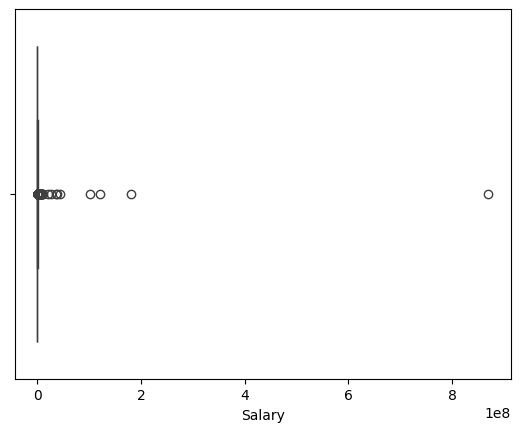

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame and 'Salary' is the column you want to plot
sns.boxplot(x=df['Salary'])
plt.show()

In [ ]:
#What is the size of the dataset?
len(df)

27989

In [ ]:
df.isna().sum()# This shows you the total number of missing values per column

,0
Timestamp,0
Age,0
Industry,72
Job title,0
Context,20749
Salary,0
Compensation,7270
Currency,0
Other currency,27792
Salary context,24955


## 1. Incomplete data/Missing values

* [Reference] https://www.kaggle.com/code/parulpandey/a-guide-to-handling-missing-values-in-python#Treating-Missing-values

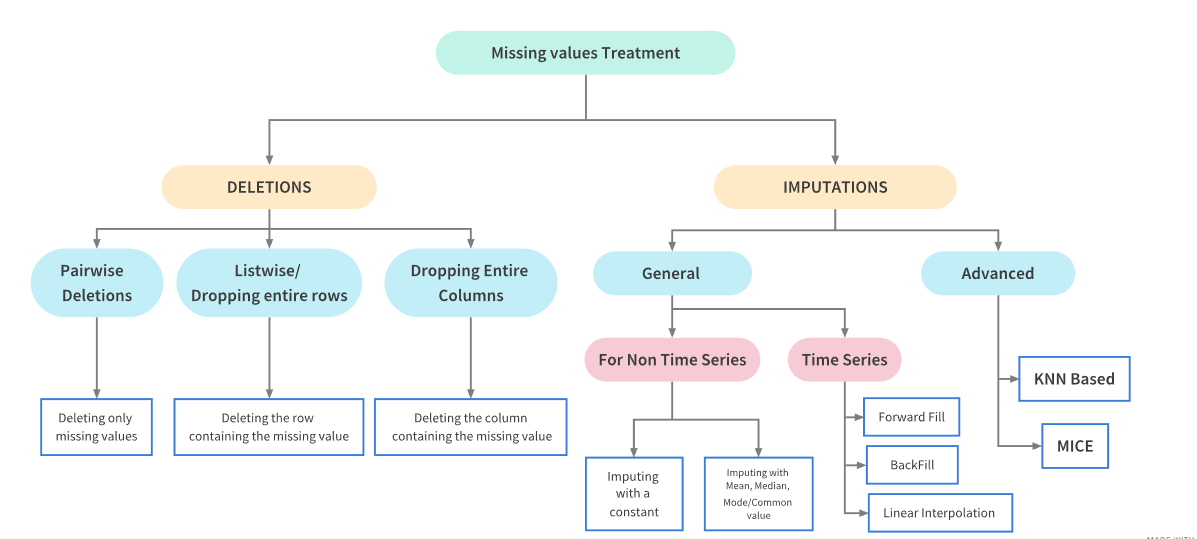

* There are 3 columns which has a lot of nulls/missing data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27989 entries, 0 to 27988
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Timestamp                           27989 non-null  object 
 1   Age                                 27989 non-null  object 
 2   Industry                            27917 non-null  object 
 3   Job title                           27989 non-null  object 
 4   Context                             7240 non-null   object 
 5   Salary                              27989 non-null  int64  
 6   Compensation                        20719 non-null  float64
 7   Currency                            27989 non-null  object 
 8   Other currency                      197 non-null    object 
 9   Salary context                      3034 non-null   object 
 10  Country                             27989 non-null  object 
 11  State                               22993

In [ ]:
#Write a code to return the number of rows with missing values under the column 'Compensation'?
# Hint: use isna().sum()

df.isna().sum() #this computes the missing values for all columns

df['Compensation'].isna().sum() #this computes for 'Compensation' only

7270

In [ ]:
#Write a code that returns the each column name with the number of missing values. This will come in handy later
#Output example as below

df.isna().sum()

,0
Timestamp,0
Age,0
Industry,72
Job title,0
Context,20749
Salary,0
Compensation,7270
Currency,0
Other currency,27792
Salary context,24955


## 1.1 Dropping columns with too many missing values

In [ ]:
#Drop columns 'context', 'Other currency', 'Salary context'

df = df.drop(columns=['Context','Other currency', 'Salary context'])

In [ ]:
df.head()

,Timestamp,Age,Industry,Job title,Salary,Compensation,Currency,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,55000,0.0,USD,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,54600,4000.0,GBP,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000,NaN,USD,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,62000,3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,60000,7000.0,USD,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27989 entries, 0 to 27988
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Timestamp                           27989 non-null  object 
 1   Age                                 27989 non-null  object 
 2   Industry                            27917 non-null  object 
 3   Job title                           27989 non-null  object 
 4   Salary                              27989 non-null  int64  
 5   Compensation                        20719 non-null  float64
 6   Currency                            27989 non-null  object 
 7   Country                             27989 non-null  object 
 8   State                               22993 non-null  object 
 9   City                                27909 non-null  object 
 10  Overall years of experience         27989 non-null  object 
 11  Years of experience in current job  27989

## 1.2 Quick analysis of missing values-  Compensation.

* The amount to compensate relates well with the industry

In [ ]:
x = df[df['Compensation'].isna()]
x.head()


,Timestamp,Age,Industry,Job title,Salary,Compensation,Currency,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000,NaN,USD,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
5,4/27/2021 11:02:46,25-34,Education (Higher Education),Scholarly Publishing Librarian,62000,NaN,USD,USA,New Hampshire,Hanover,8 - 10 years,2 - 4 years,Master's degree,Man,White
7,4/27/2021 11:03:00,25-34,Education (Primary/Secondary),Librarian,50000,NaN,USD,United States,Arizona,Yuma,5-7 years,5-7 years,Master's degree,Man,White
14,4/27/2021 11:03:11,18-24,Health care,Patient care coordinator,32000,NaN,CAD,Canada,NaN,Remote,1 year or less,1 year or less,College degree,Woman,White
17,4/27/2021 11:03:19,45-54,Art & Design,graphic designer,59000,NaN,USD,usa,California,Pomona,21 - 30 years,21 - 30 years,College degree,Woman,White


*  One sensible way is to impute NaN values for Compensation based on the industry. For example below, we have records where other people in the Librarian industry receives zero compensation.

* So similarly, we can impute 0 in the compensation where the industry is Librarian

In [ ]:
#Let's take a look at compensation for librarian from the original dataframe
df[df['Industry']=='Librarian']

,Timestamp,Age,Industry,Job title,Salary,Compensation,Currency,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race
2450,4/27/2021 11:44:24,35-44,Librarian,"Digital Initiatives Archivist, Senior",66703,0.0,USD,United States,Florida,Ft. Lauderdale,11 - 20 years,11 - 20 years,Master's degree,Woman,White
13187,4/28/2021 12:11:05,35-44,Librarian,Adult Services Librarian,45700,NaN,USD,USA,New York,Johnson City,8 - 10 years,5-7 years,Master's degree,Non-binary,White
21760,4/30/2021 16:24:12,25-34,Librarian,teen librarian,40700,0.0,USD,USA,Ohio,Marion,8 - 10 years,11 - 20 years,Master's degree,Woman,White


## 1.3 Dropping missing values

* We can drop missing values here using dropna() function.

* If we do dropna() without specifying any parameter, it will drop rows that has even 1 missing values

* If we do dropna(thresh=2) it will drop rows that has more than 2 missing values

* If we do dropna(how=all) it will drop only rows where all values are missing

* [Ref] https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html



In [ ]:

df_dropna = df.dropna()
df_dropna.info()
#Compare the number of rows with the original dataset
#16974 rows vs originally 27989 rows

<class 'pandas.core.frame.DataFrame'>
Index: 16974 entries, 0 to 27986
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Timestamp                           16974 non-null  object 
 1   Age                                 16974 non-null  object 
 2   Industry                            16974 non-null  object 
 3   Job title                           16974 non-null  object 
 4   Salary                              16974 non-null  int64  
 5   Compensation                        16974 non-null  float64
 6   Currency                            16974 non-null  object 
 7   Country                             16974 non-null  object 
 8   State                               16974 non-null  object 
 9   City                                16974 non-null  object 
 10  Overall years of experience         16974 non-null  object 
 11  Years of experience in current job  16974 non-

## 1.4 Impute missing values with most frequent

* A simple method where we don't analyse per column.

* We can impute missing values for all related columns using most frequent.

* Imputed values can be the mean, median. This is changed in the 'strategy' parameter.

* There are other simple methods for imputing missing values. Eg fill.na()



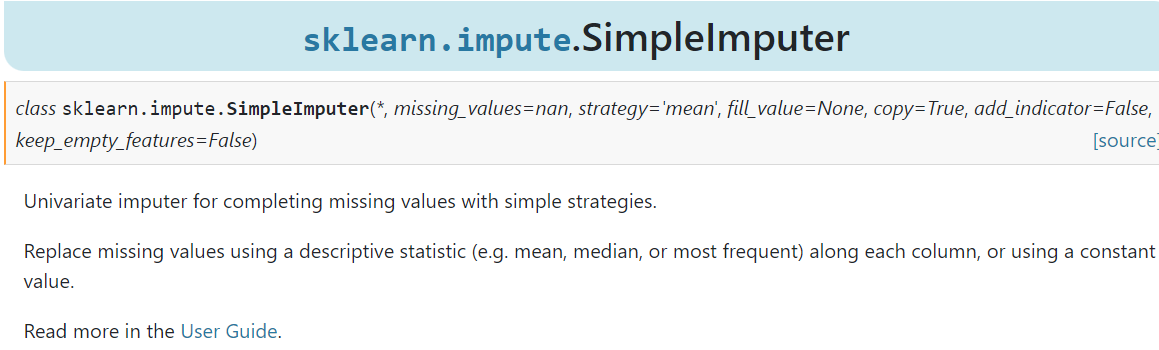

In [ ]:
from sklearn.impute import SimpleImputer

#df2 = df.copy() #so that you are not overwriting the original dataframe, #overiding

#df_impute = df.copy() #many times it is wise to copy the dataframe rather than reassign it
most_frequent_imputer = SimpleImputer(strategy='most_frequent') #change strategy here if want to use median etc.
df.iloc[:,:] = most_frequent_imputer.fit_transform(df)
df.head()

,Timestamp,Age,Industry,Job title,Salary,Compensation,Currency,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,55000,0.0,USD,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,54600,4000.0,GBP,United Kingdom,California,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000,0.0,USD,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,62000,3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,60000,7000.0,USD,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


In [ ]:
df.isna().sum()

,0
Timestamp,0
Age,0
Industry,0
Job title,0
Salary,0
Compensation,0
Currency,0
Country,0
State,0
City,0


# 2. Noisy data
* Noise can be random errors and/or outliers.
* It can also be non-sensible data

## 2.1 Remove outliers

* Use boxplot or histograms to find outliers (df.boxplot() or df.hist())

* Outliers are values that are waaay higher or lower than most of the data. Usually there are not many data points like this. So we can consider this as noise

* It seems salary and compensation has many outliers. Let's remove them

<Axes: >

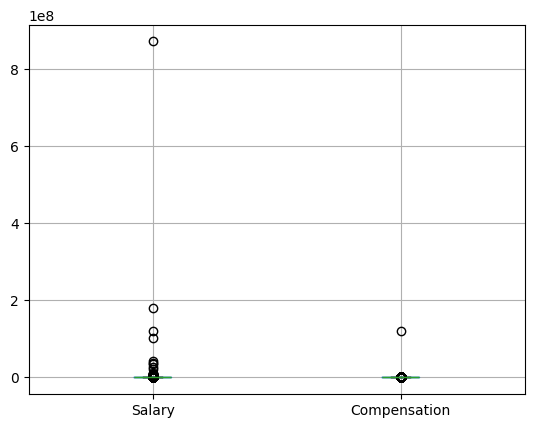

In [ ]:
df.boxplot() # There are

* Can remove using stats [Ref] https://stackoverflow.com/questions/23199796/detect-and-exclude-outliers-in-a-pandas-dataframe

* Can also remove manually

<Axes: >

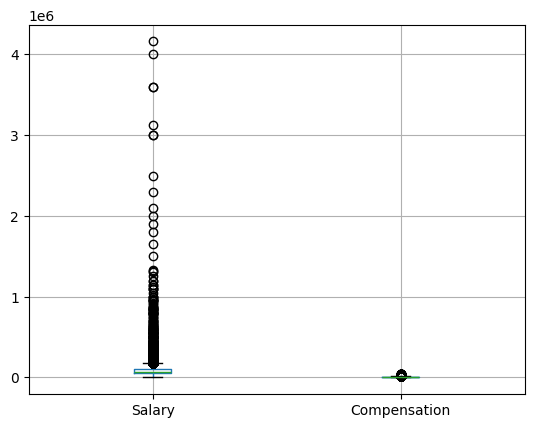

In [ ]:
from scipy import stats
df=df[(np.abs(stats.zscore(df['Salary'])) < 0.75)] #replace 1.5 with your own threshold
df=df[(np.abs(stats.zscore(df['Compensation'])) < 0.75)]

df.boxplot()

## 2.2 Remove non sensible values
* Use df.describe()

In [ ]:
df['Salary'].min()

17000

In [ ]:

print(df['Salary'].describe())
print('is it really true that the min salary is zero?::',df['Salary'].min())



'''


salary_zero = df[df['Salary']==0]
print(len(salary_zero))


df[df['Salary']==0].count()
df[df['Salary']==0]['Salary'].count()

df[df['Salary']==0]


'''


count    2.634600e+04
mean     8.744741e+04
std      8.984780e+04
min      1.700000e+04
25%      5.400000e+04
50%      7.500000e+04
75%      1.030000e+05
max      4.160000e+06
Name: Salary, dtype: float64
is it really true that the min salary is zero?:: 17000


"\n\n\nsalary_zero = df[df['Salary']==0]\nprint(len(salary_zero))\n\n\ndf[df['Salary']==0].count()\ndf[df['Salary']==0]['Salary'].count()\n\ndf[df['Salary']==0]\n\n\n"

# How to Subset

<Axes: >

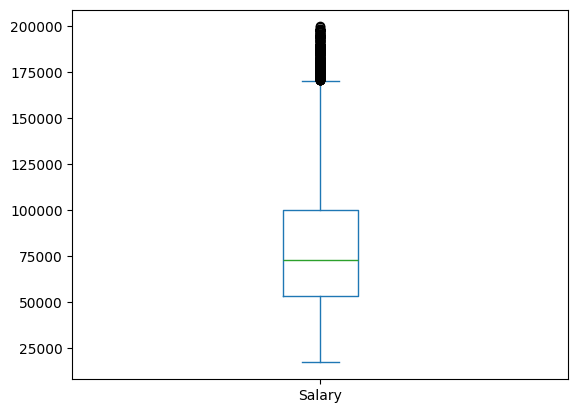

In [ ]:
#Subsetting/Slicing : is taking a subset of the dataset

df2 = df.copy()

a = df2[df2['Salary']<200000]
a['Salary'].plot(kind='box')



In [ ]:
df[df['Salary']<500]

df = df[df['Salary']>=17000] #any data that has annual salary of less than 17k is non sensible. so we 'drop' it by subset



# 3. Inconsistent data

 * Find 'duplicated' rows. For example 'University Malaya' , 'UM', 'Universiti Malaya' should be the same. One way is to use fuzzy matching (fuzzywuzzy package)
 * Find typos
 * Warning , this is very tedious

 * [Ref] https://www.kaggle.com/code/ramjan135/data-cleaning-challenge-inconsistent-data-entry

## 3.1 Check for each columns. Example is 'Gender'

* Print out the unique items for each columns using df['column].unique()
* You'll see some are not that unique. Using the 'Gender' column, I found that there is 'Other or prefer not to answer' and 'Prefer not to answer'. Let's just group them into 'Other'

* Try checking columns with the lowest number of unique itmes first

In [ ]:
df['Gender'].unique()

array(['Woman', 'Non-binary', 'Man', 'Prefer Not Answer',
       'Prefer not to answer'], dtype=object)

In [ ]:

print('--Columns and their number of unique items--')

df.nunique()

--Columns and their number of unique items--


,0
Timestamp,23083
Age,7
Industry,1166
Job title,13671
Salary,3410
Compensation,613
Currency,11
Country,342
State,125
City,4646


* Check the unique items for Gender

In [ ]:
#Forcing colab to print out all in the y (stored as ndarray)
import sys
import numpy
numpy.set_printoptions(threshold=sys.maxsize)

#y = df['Industry'].unique()
y = df['Gender'].unique()
print(f'There are {len(y)} unique items ')
print(y)

There are 5 unique items 
['Woman' 'Non-binary' 'Man' 'Other or prefer not to answer'
 'Prefer not to answer']


* Remove redundancy by using df.replace()

In [ ]:
df = df.replace('Other or prefer not to answer','Prefer Not Answer')
#df = df.replace('Prefer not to answer','Prefer Not to Answer')


* Check whether the values have been replaced or not

In [ ]:
y = df['Gender'].unique()
print(f'There are {len(y)} unique items ')
print(y)

There are 5 unique items 
['Woman' 'Non-binary' 'Man' 'Prefer Not Answer' 'Prefer not to answer']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26346 entries, 0 to 27988
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Timestamp                           26346 non-null  object 
 1   Age                                 26346 non-null  object 
 2   Industry                            26346 non-null  object 
 3   Job title                           26346 non-null  object 
 4   Salary                              26346 non-null  int64  
 5   Compensation                        26346 non-null  float64
 6   Currency                            26346 non-null  object 
 7   Country                             26346 non-null  object 
 8   State                               26346 non-null  object 
 9   City                                26346 non-null  object 
 10  Overall years of experience         26346 non-null  object 
 11  Years of experience in current job  26346 non-